# Merchant categorization - DistilBERT via the HuggingFace Trainer


In [41]:
!nvidia-smi

Tue Aug 18 00:08:21 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   69C    P0             31W /   70W |    1405MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [1]:
!pip install -q -U transformers datasets accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 37.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 21.3 MB/s eta 0:00:00:00:0100:01


In [2]:
import os
import numpy as np
import pandas as pd
import torch

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
device

device(type='cuda')

## Load the dataset from Google Drive

In [3]:
# Mount Drive (no-op outside Colab, so the notebook also runs locally).
try:
    from google.colab import drive
    drive.mount('/content/drive')
    DRIVE_DIR = "/content/drive/MyDrive"
except ImportError:
    DRIVE_DIR = "."

DATA_PATH = os.path.join(DRIVE_DIR, "cc_merchants_overture.csv")
OUTPUT_DIR = os.path.join(DRIVE_DIR, "cc_tool_models")
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("data:  ", DATA_PATH)
print("output:", OUTPUT_DIR)

Mounted at /content/drive
data:   /content/drive/MyDrive/cc_merchants_overture.csv
output: /content/drive/MyDrive/cc_tool_models


In [4]:
df_data = pd.read_csv(DATA_PATH)
print(df_data.shape)
df_data.head()

(91818, 3)


,transaction_description,category,merchant
0,MULTI-ENTREPOTS ST-GERMAIN #2895,Home,Multi-Entrepots St-Germain
1,NOVA TRUCK CENTRES HALIFAX NS,Transport,Nova Truck Centres
2,MIKE'S FAMILY BILLIARDS#7370,Health,Mike's Family Billiards
3,TST* CAR-FULL ACCOUNTING,Financial,Car-Full Accounting
4,SP * LE QG,Entertainment,Le QG


In [5]:
# Sanity check the shape of the data before anything trains on it.
print("rows:               ", len(df_data))
print("unique descriptors: ", df_data["transaction_description"].nunique())
print("unique merchants:   ", df_data["merchant"].nunique())
df_data["category"].value_counts()

rows:                91818
unique descriptors:  91818
unique merchants:    90579


,count
category,
Entertainment,8448
Services,8386
Financial,8278
Shopping,8223
Travel,8199
Dining,8147
Transport,8134
Health,8131
Other,8111


## Model input

The raw statement descriptor, whitespace-collapsed and nothing else. `distilbert-base-uncased`
lowercases in the tokenizer, so casing needs no handling here.

In [6]:
TEXT_COL = "text"

df_data[TEXT_COL] = df_data["transaction_description"].map(lambda s: " ".join(str(s).split()))

# Nothing should reduce to an empty string - that would be an unlabellable row.
print("rows reduced to empty:", int((df_data[TEXT_COL].str.len() == 0).sum()))
df_data[[TEXT_COL, "merchant", "category"]].sample(10, random_state=3)

rows reduced to empty: 0


,text,merchant,category
26219,EARTH SAVER,Earth Saver,Transport
53618,MACQUARRIES PHARMASAVE BARRINGTO,MacQuarries Pharmasave Barrington Passage,Health
54207,PNEUS MECANIQUE VERDUN 6583 MONT,Pneus Mecanique Verdun,Transport
90558,VILLAGE GROCER#446,Village Grocer,Groceries
48620,TST* DOJO D'ARTS MARTIAUX,Dojo d'Arts Martiaux,Entertainment
37448,DUNDAS LIFE STORE #1365,Dundas Life,Financial
59978,THE COLLECTIVE GOOD STORE #111,The Collective Good,Home
35150,AU JARDIN DES ROY#6432,Au Jardin Des Roy,Groceries
30700,CHRISTOPHER'S MEAT MARKET,Christopher's Meat Market,Groceries
65224,PRAVADA FLOORS,Pravada Floors,Home


## Label encoding


In [7]:
target_list = sorted(df_data["category"].unique())
NUM_LABELS = len(target_list)

# Guard against a stray/misspelled category sneaking in from the CSV.
CANONICAL = {
    "Groceries", "Dining", "Transport", "Travel", "Shopping", "Utilities",
    "Health", "Entertainment", "Home", "Services", "Financial", "Other",
}
unexpected = set(target_list) - CANONICAL
assert not unexpected, f"non-canonical categories in the data: {unexpected}"

label2id = {name: i for i, name in enumerate(target_list)}
id2label = {i: name for name, i in label2id.items()}
df_data["label"] = df_data["category"].map(label2id)

print(NUM_LABELS, "labels")
target_list

12 labels


['Dining',
 'Entertainment',
 'Financial',
 'Groceries',
 'Health',
 'Home',
 'Other',
 'Services',
 'Shopping',
 'Transport',
 'Travel',
 'Utilities']

## Train / validation / test split

70 / 15 / 15, stratified on `category`, so all three splits carry the corpus's class
proportions instead of whatever the draw happened to produce.

With 91,818 rows a plain random split was already close, so this is a small correction. It
earns its keep on `Utilities`, the one thin class at 1.75% (1,608 rows against ~8,100 for
every other category): it lands ~241 rows in test, where random sampling swings it by a
dozen or so and stratification pins it exactly. That firms up the per-class recall in the
classification report rather than moving overall accuracy.

What stratification does **not** do is keep a merchant on one side of the split - it
balances labels, not groups. The `GroupShuffleSplit` that used to sit here did that, and
the difference is the ~155 online-only brands `build_overture_dataset.py` renders in 9
descriptor forms each: **199 of the 13,773 test rows (1.45%) have their merchant in train
too**, so `WAYFAIR.CA` is scored after `WAYFAIR.COM` was memorized. Grouped, that count was
0. Measured cost: test accuracy 0.7105 grouped vs 0.7208 ungrouped, otherwise identical
runs. So these numbers are the more optimistic of the two, and are not comparable to the
project's grouped-split baselines.

The split seeds (77 / 88) are fixed on purpose. To measure run-to-run variance, vary `SEED`
below and leave these alone, otherwise the split moves along with the initialization and
the two effects are impossible to separate.

In [8]:
from sklearn.model_selection import StratifiedShuffleSplit

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=77)
train_idx, holdout_idx = next(sss.split(df_data, df_data["category"]))
df_train = df_data.iloc[train_idx].reset_index(drop=True)
df_holdout = df_data.iloc[holdout_idx].reset_index(drop=True)

# Stratify the second split on the HOLDOUT's labels, not df_data's. By this point the frame
# being halved is df_holdout, and passing the full label column raises a length mismatch.
sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.50, random_state=88)
test_idx, valid_idx = next(sss2.split(df_holdout, df_holdout["category"]))
df_test = df_holdout.iloc[test_idx].reset_index(drop=True)
df_valid = df_holdout.iloc[valid_idx].reset_index(drop=True)

print(f"Train: {df_train.shape}, Valid: {df_valid.shape}, Test: {df_test.shape}")

Train: (64272, 5), Valid: (13773, 5), Test: (13773, 5)


In [9]:
df_train

,transaction_description,category,merchant,text,label
0,THE FALAFEL GUYS STORE #7360,Dining,The Falafel Guys,THE FALAFEL GUYS STORE #7360,0
1,POS PURCHASE JASPER PARK LODGE,Travel,Jasper Park Lodge,POS PURCHASE JASPER PARK LODGE,10
2,KICKS SPORTS#7281,Shopping,Kicks Sports,KICKS SPORTS#7281,8
3,CHIN RADIO CANADA#7812,Other,CHIN Radio Canada,CHIN RADIO CANADA#7812,6
4,MARTIBO SPORTS,Shopping,Martibo Sports,MARTIBO SPORTS,8
...,...,...,...,...,...
64267,SQ *ARRAYMUSIC,Entertainment,Arraymusic,SQ *ARRAYMUSIC,1
64268,SQ *HAMILTON SCHOOL OF MUSIC,Services,Hamilton School of Music,SQ *HAMILTON SCHOOL OF MUSIC,7
64269,A LA MINE D'ART ANNA LABERGE QC,Shopping,A la Mine d'Art Anna Laberge,A LA MINE D'ART ANNA LABERGE QC,8
64270,AU COEUR DE LA BEAUTE,Services,Au Coeur De La Beaute,AU COEUR DE LA BEAUTE,7


In [10]:
# Hyperparameters 
MODEL_NAME = "distilbert-base-uncased"

MAX_LEN = 32     # descriptors are short - 32 wordpieces covers them comfortably
TRAIN_BATCH_SIZE = 16
EVAL_BATCH_SIZE = 16
EPOCHS = 10
LEARNING_RATE = 1e-05

WEIGHT_DECAY = 0.01     
DROPOUT = 0.2           # classifier-head dropout (config.seq_classif_dropout)
WARMUP_RATIO = 0.1      # fraction of total steps spent ramping the LR up from 0

LABEL_SMOOTHING = 0.1

# Early stopping: give up after this many evals with no new best validation accuracy.
PATIENCE = 3

SEED = 42

## Tokenize



In [11]:
from datasets import Dataset
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


def to_dataset(frame):
    """pandas -> tokenized HF Dataset."""
    d = Dataset.from_pandas(frame[[TEXT_COL, "label"]], preserve_index=False)
    return d.map(
        lambda b: tokenizer(b[TEXT_COL], truncation=True, max_length=MAX_LEN),
        batched=True,
    )


train_ds = to_dataset(df_train)
valid_ds = to_dataset(df_valid)
test_ds = to_dataset(df_test)

train_ds

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/64272 [00:00<?, ? examples/s]

Map:   0%|          | 0/13773 [00:00<?, ? examples/s]

Map:   0%|          | 0/13773 [00:00<?, ? examples/s]

Dataset({
    features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 64272
})

In [12]:
# How long are the descriptors, really? Confirms MAX_LEN is not truncating anything.
lens = [len(x) for x in train_ds["input_ids"]]
print("token length - mean:", round(float(np.mean(lens)), 1),
      " p99:", int(np.percentile(lens, 99)), " max:", max(lens))

token length - mean: 9.1  p99: 15  max: 32


## Model


In [13]:
from transformers import DistilBertForSequenceClassification, set_seed

set_seed(SEED)

model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=id2label,
    label2id=label2id,
    seq_classif_dropout=DROPOUT,
)

model.config.pooling = "cls"

print("pooling:     ", model.config.pooling)
print("head dropout:", model.config.seq_classif_dropout)
print(f"trainable params: {sum(p.numel() for p in model.parameters()):,} (full fine-tune)")

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


pooling:      cls
head dropout: 0.2
trainable params: 66,962,700 (full fine-tune)


## Training


The one thing `Trainer` will not give you is training *accuracy* per epoch - it logs
training loss only, accumulated with dropout on. Since the train/val gap is the number
worth watching, `TrainAccuracyCallback` adds it back by re-scoring the training set in eval
mode after each epoch. That is one extra forward pass over 70% of the data per epoch;
remove the callback if the wall-clock matters more than the gap.

In [14]:
from sklearn.metrics import accuracy_score, f1_score
from transformers import (
    DataCollatorWithPadding,
    EarlyStoppingCallback,
    Trainer,
    TrainerCallback,
    TrainingArguments,
)


def compute_metrics(eval_pred):
    logits, gold = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(gold, preds),
        "f1_macro": f1_score(gold, preds, average="macro"),
    }


class TrainAccuracyCallback(TrainerCallback):
    """Log train accuracy next to val accuracy so the gap is visible per epoch.

    Calls `predict`, not `evaluate`: `evaluate` fires `on_evaluate` again, which would
    recurse straight back into this callback.
    """

    def __init__(self, trainer, dataset):
        self.trainer = trainer
        self.dataset = dataset
        self.history = []

    def on_evaluate(self, args, state, control, metrics=None, **kwargs):
        if metrics is None or "eval_accuracy" not in metrics:
            return
        m = self.trainer.predict(self.dataset, metric_key_prefix="train_eval").metrics
        row = {
            "epoch": round(state.epoch),
            "train_loss": m["train_eval_loss"],
            "val_loss": metrics["eval_loss"],
            "train_acc": m["train_eval_accuracy"],
            "val_acc": metrics["eval_accuracy"],
        }
        row["gap"] = row["train_acc"] - row["val_acc"]
        self.history.append(row)
        print(f"  train_loss={row['train_loss']:.4f}, val_loss={row['val_loss']:.4f} "
              f"train_acc={row['train_acc']:.4f}, val_acc={row['val_acc']:.4f}, "
              f"gap={row['gap']:.4f}")


# The Trainer takes warmup as a step count; ratio -> steps needs the epoch length.
steps_per_epoch = int(np.ceil(len(train_ds) / TRAIN_BATCH_SIZE))
total_steps = steps_per_epoch * EPOCHS

args = TrainingArguments(
    output_dir=os.path.join(OUTPUT_DIR, "distilbert-merchant-trainer"),
    learning_rate=LEARNING_RATE,
    per_device_train_batch_size=TRAIN_BATCH_SIZE,
    per_device_eval_batch_size=EVAL_BATCH_SIZE,
    num_train_epochs=EPOCHS,
    weight_decay=WEIGHT_DECAY,
    label_smoothing_factor=LABEL_SMOOTHING,
    warmup_steps=int(WARMUP_RATIO * total_steps),
    lr_scheduler_type="linear",     # linear decay after warmup - the default
    max_grad_norm=1.0,              # the clip_grad_norm_ from the manual loop; also default
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,    # replaces the manual best-checkpoint bookkeeping
    metric_for_best_model="accuracy",
    greater_is_better=True,
    save_total_limit=1,
    logging_steps=50,
    seed=SEED,
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=valid_ds,
    processing_class=tokenizer,     # renamed from `tokenizer=` in recent transformers
    data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=PATIENCE)],
)

train_acc_cb = TrainAccuracyCallback(trainer, train_ds)
trainer.add_callback(train_acc_cb)

print(f"steps/epoch: {steps_per_epoch}  total: {total_steps}  "
      f"warmup: {int(WARMUP_RATIO * total_steps)}")
print(f"lr={LEARNING_RATE} weight_decay={WEIGHT_DECAY} dropout={DROPOUT} "
      f"label_smoothing={LABEL_SMOOTHING} patience={PATIENCE}")

steps/epoch: 4017  total: 40170  warmup: 4017
lr=1e-05 weight_decay=0.01 dropout=0.2 label_smoothing=0.1 patience=3


In [15]:
train_output = trainer.train()
train_output.metrics

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,1.315066,1.357756,0.666521,0.651722
2,1.239479,1.260028,0.704785,0.690732
3,1.169629,1.241461,0.716039,0.703823
4,1.096340,1.246039,0.718289,0.707824
5,1.014430,1.272278,0.714732,0.704319
6,0.946095,1.300263,0.716184,0.706756
7,0.922914,1.317287,0.712045,0.702900


  train_loss=1.2933, val_loss=1.3578 train_acc=0.6894, val_acc=0.6665, gap=0.0229


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  train_loss=1.1200, val_loss=1.2600 train_acc=0.7618, val_acc=0.7048, gap=0.0570


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

  train_loss=0.8115, val_loss=1.3003 train_acc=0.8925, val_acc=0.7162, gap=0.1763


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  train_loss=0.7718, val_loss=1.3173 train_acc=0.9104, val_acc=0.7120, gap=0.1983


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'train_runtime': 1346.1687,
 'train_samples_per_second': 477.444,
 'train_steps_per_second': 29.84,
 'total_flos': 1531558955104128.0,
 'train_loss': 1.1565406233196285,
 'epoch': 7.0}

       train_loss  val_loss  train_acc  val_acc     gap
epoch                                                  
1          1.2933    1.3578     0.6894   0.6665  0.0229
2          1.1200    1.2600     0.7618   0.7048  0.0570
3          1.0156    1.2415     0.8060   0.7160  0.0900
4          0.9364    1.2460     0.8410   0.7183  0.1227
5          0.8695    1.2723     0.8675   0.7147  0.1528
6          0.8115    1.3003     0.8925   0.7162  0.1763
7          0.7718    1.3173     0.9104   0.7120  0.1983


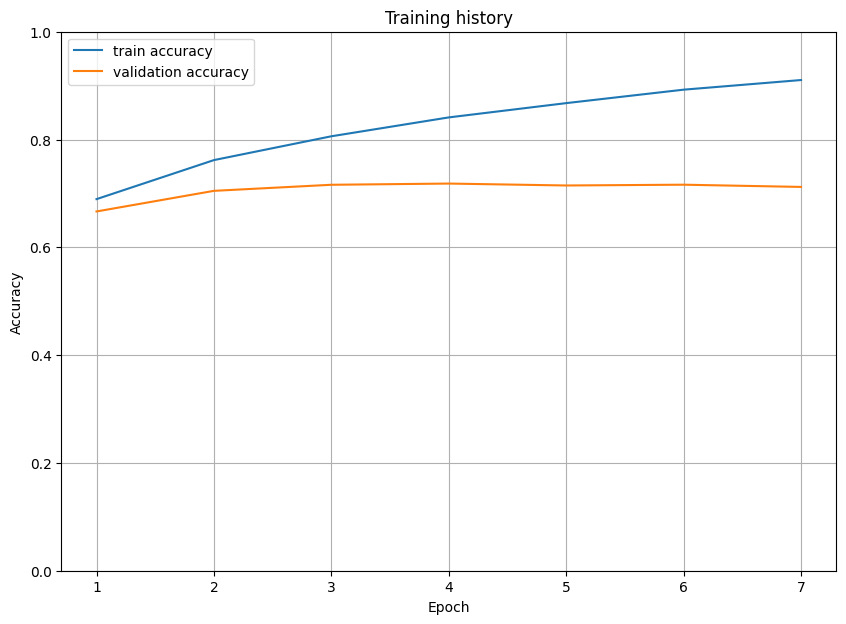

In [16]:
# The per-epoch table the manual loop printed, rebuilt from the callback's history.
import matplotlib.pyplot as plt

per_epoch = pd.DataFrame(train_acc_cb.history).set_index("epoch")
print(per_epoch.round(4))

plt.rcParams["figure.figsize"] = (10, 7)
plt.plot(per_epoch.index, per_epoch["train_acc"], label="train accuracy")
plt.plot(per_epoch.index, per_epoch["val_acc"], label="validation accuracy")
plt.title("Training history")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend()
plt.ylim([0, 1])
plt.grid()

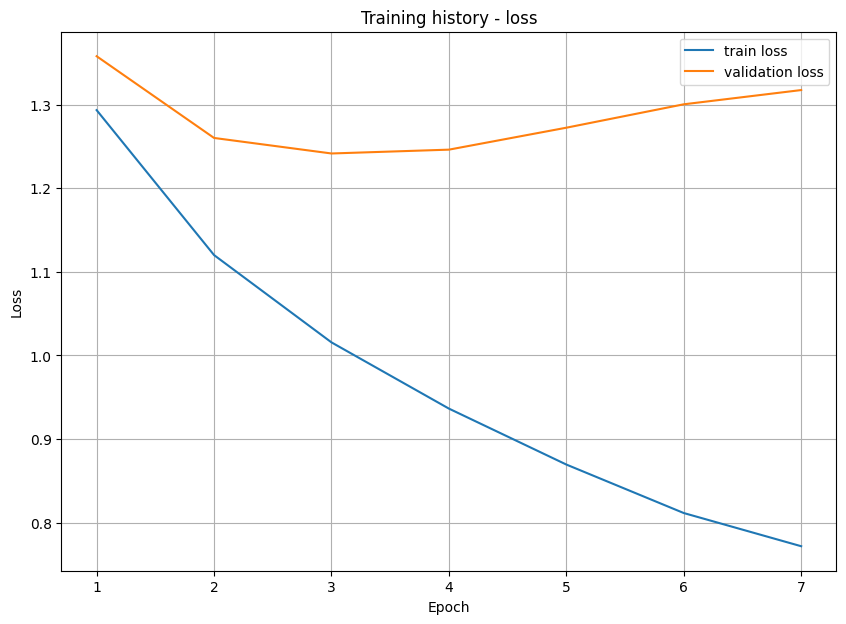

In [17]:

plt.figure(figsize=(10, 7))
plt.plot(per_epoch.index, per_epoch["train_loss"], label="train loss")
plt.plot(per_epoch.index, per_epoch["val_loss"], label="validation loss")
plt.title("Training history - loss")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend()
plt.grid()

## Evaluation



In [18]:
pred = trainer.predict(test_ds)
pred.metrics

{'test_loss': 1.2334600687026978,
 'test_accuracy': 0.7246787192332825,
 'test_f1_macro': 0.7160629241867879,
 'test_runtime': 8.502,
 'test_samples_per_second': 1619.965,
 'test_steps_per_second': 101.27}

In [19]:
from sklearn.metrics import classification_report, confusion_matrix

prediction_probs = torch.softmax(torch.tensor(pred.predictions), dim=1)
predictions = prediction_probs.argmax(dim=1).numpy()
target_values = pred.label_ids
texts = test_ds[TEXT_COL]

print(classification_report(target_values, predictions, target_names=target_list))

               precision    recall  f1-score   support

       Dining       0.72      0.78      0.75      1222
Entertainment       0.78      0.71      0.74      1267
    Financial       0.76      0.87      0.81      1242
    Groceries       0.76      0.72      0.74      1212
       Health       0.85      0.74      0.79      1220
         Home       0.67      0.69      0.68      1211
        Other       0.74      0.73      0.74      1217
     Services       0.57      0.55      0.56      1258
     Shopping       0.57      0.58      0.57      1233
    Transport       0.82      0.82      0.82      1220
       Travel       0.78      0.80      0.79      1230
    Utilities       0.59      0.60      0.60       241

     accuracy                           0.72     13773
    macro avg       0.72      0.72      0.72     13773
 weighted avg       0.73      0.72      0.72     13773



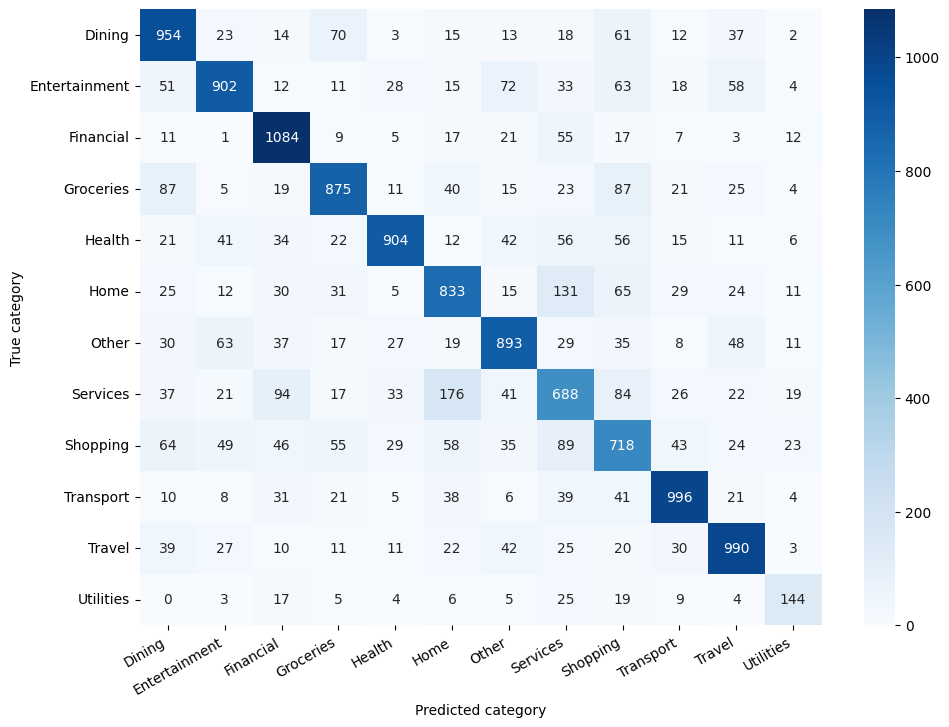

In [20]:
import seaborn as sns


def show_confusion_matrix(confusion_matrix):
    hmap = sns.heatmap(confusion_matrix, annot=True, fmt="d", cmap="Blues")
    hmap.yaxis.set_ticklabels(hmap.yaxis.get_ticklabels(), rotation=0, ha='right')
    hmap.xaxis.set_ticklabels(hmap.xaxis.get_ticklabels(), rotation=30, ha='right')
    plt.ylabel('True category')
    plt.xlabel('Predicted category')


plt.rcParams["figure.figsize"] = (11, 8)
cm = confusion_matrix(target_values, predictions)
df_cm = pd.DataFrame(cm, index=target_list, columns=target_list)
show_confusion_matrix(df_cm)

### Where is it going wrong?



In [21]:
errors = pd.DataFrame({
    "descriptor": texts,
    "true": [target_list[i] for i in target_values],
    "pred": [target_list[i] for i in predictions],
    "confidence": prediction_probs.max(dim=1).values.numpy().round(3),
})
errors = errors[errors["true"] != errors["pred"]]
print(f"{len(errors)} errors out of {len(texts)} test rows")
errors.sort_values("confidence", ascending=False).head(30)

3792 errors out of 13773 test rows


,descriptor,true,pred,confidence
13016,SP * BETWEEN FRIENDS NAIL,Health,Services,0.937
12410,SP * CENTRE D'ACTION BENEVOLE LE,Entertainment,Other,0.932
3323,ROBIN BURWASH COLDWELL BANKER ST,Services,Financial,0.931
5575,DOLL FUNERAL TORONTO ON,Shopping,Services,0.930
9783,LEGACY WEALTH OF RAYMOND JAMES L,Services,Financial,0.930
669,SP * STADACONA GOSPEL CHAPEL,Services,Other,0.929
7953,POS PURCHASE BROOKLIN VISION CAR,Health,Transport,0.929
6803,POS PURCHASE DON RITTER'S KARATE,Health,Entertainment,0.927
9179,POS PURCHASE FAKE AND BAKE SUNTA,Services,Dining,0.927
6506,POS PURCHASE TED'S COLLISION & B,Dining,Transport,0.927


### A more honest accuracy: split by whether the name actually carries a signal
 Rather
than removing or relabelling anything, split the SAME test set by whether the descriptor
contains a token that predicts one category >=85% of the time, using ONLY the training set
to decide what counts as a "predictive" token (so this can't leak from the test labels or
from this model's own predictions - it would be computed identically for any model).

In [22]:
import re
from collections import defaultdict

MIN_TOKEN_N = 5        # minimum occurrences in train before a token counts at all
MIN_TOKEN_SHARE = 0.85 # how dominant one category must be among those occurrences


def _tokens(s):
    return set(re.findall(r"[A-Za-z']+", s.upper()))


# Token -> category, built from TRAIN ONLY. This is the same "does the name carry a
# signal" question a char-ngram baseline answers, just simplified to whole tokens - it
# does not look at this model's predictions or at test labels, so it is not tuned to
# flatter this run.
token_category_counts = defaultdict(lambda: defaultdict(int))
for _text, _cat in zip(df_train[TEXT_COL], df_train["category"]):
    for _t in _tokens(_text):
        token_category_counts[_t][_cat] += 1

predictive_tokens = {}
for _t, _cd in token_category_counts.items():
    _n = sum(_cd.values())
    if _n < MIN_TOKEN_N:
        continue
    _top_cat, _top_n = max(_cd.items(), key=lambda kv: kv[1])
    if _top_n / _n >= MIN_TOKEN_SHARE:
        predictive_tokens[_t] = _top_cat

print(f"predictive tokens (train-only, n>={MIN_TOKEN_N}, share>={MIN_TOKEN_SHARE}): "
      f"{len(predictive_tokens):,}")

keyword_bearing = np.array([bool(_tokens(t) & predictive_tokens.keys()) for t in texts])

for _label, _mask in [("keyword-bearing", keyword_bearing), ("long-tail", ~keyword_bearing)]:
    _acc = accuracy_score(target_values[_mask], predictions[_mask])
    _f1 = f1_score(target_values[_mask], predictions[_mask], average="macro")
    print(f"{_label:16s} n={_mask.sum():5d} ({_mask.mean():.1%})  "
          f"accuracy={_acc:.4f}  f1_macro={_f1:.4f}")

print(f"\n{'overall':16s} n={len(texts):5d} (100.0%)  "
      f"accuracy={pred.metrics['test_accuracy']:.4f}  f1_macro={pred.metrics['test_f1_macro']:.4f}")

predictive tokens (train-only, n>=5, share>=0.85): 1,012
keyword-bearing  n= 5829 (42.3%)  accuracy=0.9376  f1_macro=0.9218
long-tail        n= 7944 (57.7%)  accuracy=0.5685  f1_macro=0.5749

overall          n=13773 (100.0%)  accuracy=0.7247  f1_macro=0.7161


## Predicting on raw text



In [23]:
from transformers import pipeline

clf = pipeline(
    "text-classification",
    model=trainer.model,
    tokenizer=tokenizer,
    device=0 if torch.cuda.is_available() else -1,
    truncation=True,
    max_length=MAX_LEN,
    top_k=3,
)


def predict_category(raw_text, top_k=3):
    """Whitespace-collapse only, matching TEXT_COL - no cleaning at train or predict time."""
    ranked = clf(" ".join(str(raw_text).split()))[0]
    return [(r["label"], round(r["score"], 4)) for r in ranked[:top_k]]

In [24]:
samples = [
    "AMAZON CA COM",
    "SHELL C05532 EDMONTON AB",
    "SQ *NETFLIX.COM 866-579-7172",
    "SHOPPERS DRUG MART #2189 TORONTO ON",
    "POS PURCHASE PUBLIC MOBILE",
    "TIM HORTONS #4821 CALGARY AB"
]
for s in samples:
    ranked = predict_category(s)
    top_label, top_prob = ranked[0]
    print(f"{s:38s} -> {top_label:14s} ({top_prob:.3f})")
    print(f"{'':38s}    runners-up: {ranked[1:]}")

AMAZON CA COM                          -> Shopping       (0.749)
                                          runners-up: [('Services', 0.0508), ('Utilities', 0.0398)]
SHELL C05532 EDMONTON AB               -> Transport      (0.565)
                                          runners-up: [('Home', 0.1187), ('Groceries', 0.08)]
SQ *NETFLIX.COM 866-579-7172           -> Entertainment  (0.929)
                                          runners-up: [('Other', 0.0103), ('Services', 0.01)]
SHOPPERS DRUG MART #2189 TORONTO ON    -> Health         (0.866)
                                          runners-up: [('Shopping', 0.0285), ('Groceries', 0.0281)]
POS PURCHASE PUBLIC MOBILE             -> Utilities      (0.787)
                                          runners-up: [('Shopping', 0.1136), ('Services', 0.0327)]
TIM HORTONS #4821 CALGARY AB           -> Dining         (0.886)
                                          runners-up: [('Groceries', 0.0281), ('Entertainment', 0.0167)]


## Save the model for inference

`save_model` writes the weights plus the config (including `id2label` and `pooling`), and
`processing_class=tokenizer` means the tokenizer is saved with it - so the folder needs no
network at load time and no `target_list` shipped alongside.

In [25]:
SAVE_DIR = os.path.join(OUTPUT_DIR, "distilbert-merchant-trainer-best")

model.config.trained_on = os.path.basename(DATA_PATH)
model.config.val_accuracy = round(float(trainer.state.best_metric), 4)
model.config.test_accuracy = round(float(pred.metrics["test_accuracy"]), 4)
model.config.max_len = MAX_LEN

trainer.save_model(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)

print("saved to", SAVE_DIR)
for f in sorted(os.listdir(SAVE_DIR)):
    print(f"  {f:28s} {os.path.getsize(os.path.join(SAVE_DIR, f)):>12,} bytes")
print()
print("pooling:      ", model.config.pooling)
print("trained_on:   ", model.config.trained_on)
print("val_accuracy: ", model.config.val_accuracy)
print("test_accuracy:", model.config.test_accuracy)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

saved to /content/drive/MyDrive/cc_tool_models/distilbert-merchant-trainer-best
  config.json                         1,266 bytes
  model.safetensors             267,863,328 bytes
  tokenizer.json                    711,493 bytes
  tokenizer_config.json                 351 bytes
  training_args.bin                   5,265 bytes

pooling:       cls
trained_on:    cc_merchants_overture.csv
val_accuracy:  0.7183
test_accuracy: 0.7247


In [26]:
# Round-trip check: rebuild from the exported folder ALONE, then confirm it agrees with the
# model in memory. If this passes, the folder is everything inference needs.
from transformers import AutoModelForSequenceClassification

reloaded_tok = AutoTokenizer.from_pretrained(SAVE_DIR)
reloaded = AutoModelForSequenceClassification.from_pretrained(SAVE_DIR).to(device).eval()
assert reloaded.config.pooling == "cls", "checkpoint config does not record cls pooling"

reloaded_clf = pipeline(
    "text-classification",
    model=reloaded,
    tokenizer=reloaded_tok,
    device=0 if torch.cuda.is_available() else -1,
    truncation=True,
    max_length=reloaded.config.max_len,
    top_k=1,
)

checks = ["AMAZON.CA", "TIM HORTONS #4821 CALGARY AB", "POS PURCHASE PUBLIC MOBILE",
          "NETFLIX.COM", "SHELL C05532 EDMONTON AB", "SHOPPERS DRUG MART #2189 TORONTO ON"]
identical = True
for s in checks:
    got = reloaded_clf(" ".join(s.split()))[0][0]
    ref_label, ref_prob = predict_category(s)[0]
    ok = got["label"] == ref_label and abs(got["score"] - ref_prob) < 1e-3
    identical &= ok
    print(f"  {'ok ' if ok else '!! '}{s:38s} exported={got['label']:14s}({got['score']:.3f})  "
          f"in-memory={ref_label}({ref_prob:.3f})")

print("\nround-trip identical:", identical)
if not identical:
    print("MISMATCH - the export is missing something. Check config.pooling and MAX_LEN "
          "before using this folder anywhere.")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


  ok AMAZON.CA                              exported=Shopping      (0.916)  in-memory=Shopping(0.916)
  ok TIM HORTONS #4821 CALGARY AB           exported=Dining        (0.886)  in-memory=Dining(0.886)
  ok POS PURCHASE PUBLIC MOBILE             exported=Utilities     (0.787)  in-memory=Utilities(0.787)
  ok NETFLIX.COM                            exported=Entertainment (0.931)  in-memory=Entertainment(0.931)
  ok SHELL C05532 EDMONTON AB               exported=Transport     (0.565)  in-memory=Transport(0.565)
  ok SHOPPERS DRUG MART #2189 TORONTO ON    exported=Health        (0.866)  in-memory=Health(0.866)

round-trip identical: True
